# Visualización de Persistencia Homológica

## A) Visión Industrial: Inspección de Defectos

### El juguete de Intuición

**Instrucciones**:


El Juguete de Intuición (15 min)
Antes de cargar imágenes reales, programen la intuición:

1. Creen dos matrices (imágenes) en numpy de 10x10.
2. Imagen A: Un cuadrado sólido (lleno de 1s).
3. Imagen B: Un cuadrado sólido con un bloque central de 3x3 lleno de 0s (un agujero).
4. Apliquen CubicalPersistence y grafiquen el Barcode.

* Observación: La Imagen B mostrará una barra larga en H₁ (agujero). ¡Detectaron un defecto sin redes neuronales!

In [1]:
# ------------ Importar Librerías
import numpy as np
import matplotlib.pyplot as plt
from gtda.homology import CubicalPersistence


# ojo!! plot_diagram de gtda 0.6.2 NO acepta el parámetro ax=
# por eso NO lo importamos y graficamos manualmente

# --- ORIGINAL (no funciona en gtda 0.6.2) ---
# from gtda.plotting import plot_diagram
# ---------------------------------------------

In [2]:
# verificamos versiones para asegurar compatibilidad
import sklearn
import gtda
print("sklearn:", sklearn.__version__)
print("gtda:", gtda.__version__)
print("numpy:", np.__version__)

sklearn: 1.3.2
gtda: 0.6.2
numpy: 1.26.4


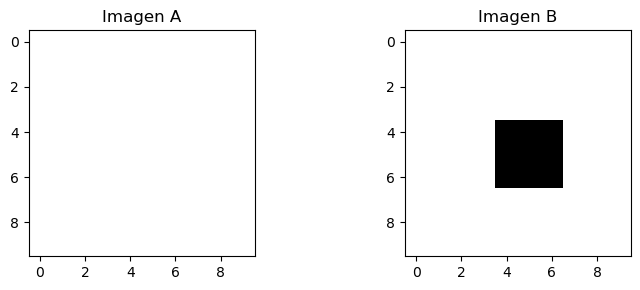

In [17]:
# Paso 1-2: crear imagen A (sólida) e imagen B (con hueco)
imagenA = np.ones((10, 10))
imagenB = np.ones((10, 10))

# Paso 3: ponemos el bloque central 3x3 en 0 -> ese es el 'agujero'
# índices 4:7 seleccionan filas/cols 4,5,6 -> centro de la matriz 10x10
imagenB[4:7, 4:7] = 0

# visualizamos las dos imágenes para confirmar
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(imagenA, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Imagen A")
axes[1].imshow(imagenB, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Imagen B")
plt.tight_layout()
plt.show()

In [4]:
# procesamos juntas las imagenes porque es la misma función

# apilamos: shape (2, 10, 10)
# .astype(np.float32) porque np.ones() crea float64 y gtda espera float32
stackImagenes = np.stack([1.0 - imagenA, 1.0 - imagenB]).astype(np.float32)

# CubicalPersistence calcula H0 (componentes) y H1 (hoyos)
cubPersistence = CubicalPersistence(homology_dimensions=[0, 1])
diagramas = cubPersistence.fit_transform(stackImagenes)

print("Shape diagramas:", diagramas.shape)
print("\nImagen A (todos los puntos):")
print(diagramas[0])
print("\nImagen B (todos los puntos):")
print(diagramas[1])

Shape diagramas: (2, 2, 3)

Imagen A (todos los puntos):
[[0. 0. 0.]
 [0. 0. 1.]]

Imagen B (todos los puntos):
[[0. 0. 0.]
 [0. 1. 1.]]


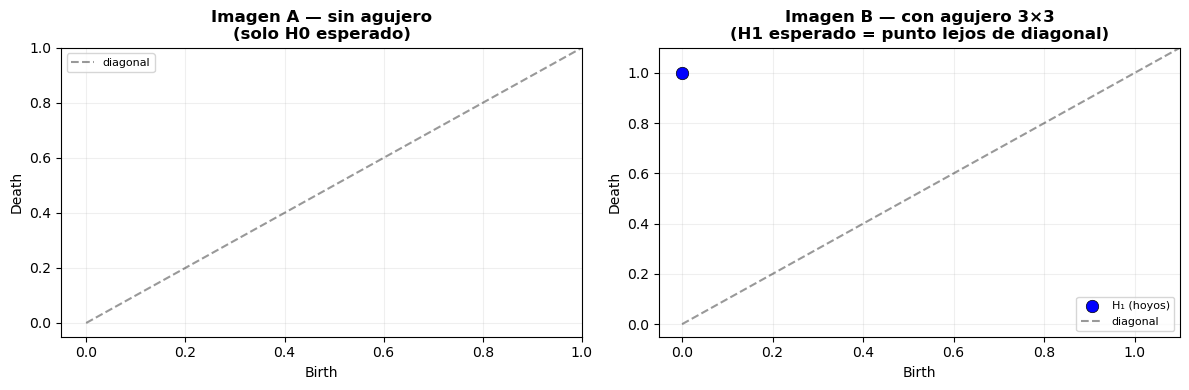

In [5]:
# graficamos los diagramas de persistencia (birth/death)
# cada punto es un hoyo: lejos de la diagonal = más persistente = más real


# --- OJOOOOO (no funciona en gtda 0.6.2 — TypeError: ax=) ---
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#
# plot_diagram(diagramas[0], ax=axes[0])
# axes[0].set_title("Imagen A — sin agujero\n(solo H0 esperado)")
#
# plot_diagram(diagramas[1], ax=axes[1])
# axes[1].set_title("Imagen B — con agujero 3×3\n(H1 esperado = punto lejos de diagonal)")
#
# plt.tight_layout()
# plt.show()


# ojo!! graficamos manualmente con matplotlib scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

titulos = [
    "Imagen A — sin agujero\n(solo H0 esperado)",
    "Imagen B — con agujero 3×3\n(H1 esperado = punto lejos de diagonal)"
]

for idx, (diagrama, titulo) in enumerate(zip(diagramas, titulos)):
    ax = axes[idx]
    
    for dim, color, label in [(0, 'red', 'H₀ (componentes)'), (1, 'blue', 'H₁ (hoyos)')]:
        # filtrar por dimensión homológica (columna 2 del diagrama)
        puntos = diagrama[diagrama[:, 2] == dim]
        # ojo!! solo quitar puntos donde birth == death (persistencia 0 = padding/ruido)
        # El filtro anterior quitaba (0,0) pero los puntos reales tienen birth=0, death>0
        puntos = puntos[puntos[:, 0] != puntos[:, 1]]  # quitar birth==death
        if len(puntos) > 0:
            ax.scatter(puntos[:, 0], puntos[:, 1], c=color, label=label, 
                       s=80, zorder=3, edgecolors='k', linewidths=0.5)
    
    # diagonal birth=death
    all_vals = diagrama[:, :2].flatten()
    all_vals = all_vals[all_vals > 0]
    if len(all_vals) > 0:
        lo, hi = 0, all_vals.max() * 1.1
    else:
        lo, hi = 0, 1
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='diagonal')
    ax.set_xlim(lo - 0.05, hi)
    ax.set_ylim(lo - 0.05, hi)
    
    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


Observación: Imagen B debería mostrar un punto azul (H₁) lejos de la diagonal.
Eso significa que se detectó un agujero persistente (creo)

### El Reto Principal

**Instrucciones**:

Procesamiento del Dataset de Kaggle:

- Tomen una muestra de 300 imágenes sanas y 300 defectuosas.
- Vital: Reduzcan la resolución a 32x32 píxeles (para que el complejo cúbico corra en segundos).
- Instancien CubicalPersistence y transformen los diagramas resultantes usando PersistenceImage.
- Aplánenlos para obtener un vector 1D por cada imagen.

In [6]:
import os
from PIL import Image


# correcion: PersistenceImage NO estaba en gtda.images jaj
# En gtda 0.6.2 está en gtda.diagrams

# --- ANTES (ImportError: cannot import name 'PersistenceImage' from 'gtda.images') ---
# from gtda.images import PersistenceImage
# ------------------------------------------------------------------------------------------
from gtda.diagrams import PersistenceImage

# rutas al dataset de casting (relativas al notebook)
ruta_def = "archive/casting_512x512/casting_512x512/def_front"
ruta_ok  = "archive/casting_512x512/casting_512x512/ok_front"

def cargar_imagenes(ruta, n=300):
    """Carga n imágenes de una carpeta,
    las convierte a escala de grises y las redimensiona a 32x32.
    El resize es vital porque el 512x512 haría el complejo cubico tardísimo."""
    imagenes = []
    archivos = sorted(os.listdir(ruta))
    for archivo in archivos:
        if not archivo.endswith(('.jpeg', '.jpg', '.png')):
            continue
        img = Image.open(os.path.join(ruta, archivo)).convert("L")
        img = img.resize((32, 32))
        imagenes.append(np.array(img, dtype=np.float32))
        if len(imagenes) >= n:
            break
    return np.array(imagenes[:n])

#defectuosas
imgs_def = cargar_imagenes(ruta_def, 300)

#las normales
imgs_ok  = cargar_imagenes(ruta_ok, 300)

print(f"Defectuosas: {imgs_def.shape}")
print(f"Sanas:       {imgs_ok.shape}")

Defectuosas: (300, 32, 32)
Sanas:       (300, 32, 32)


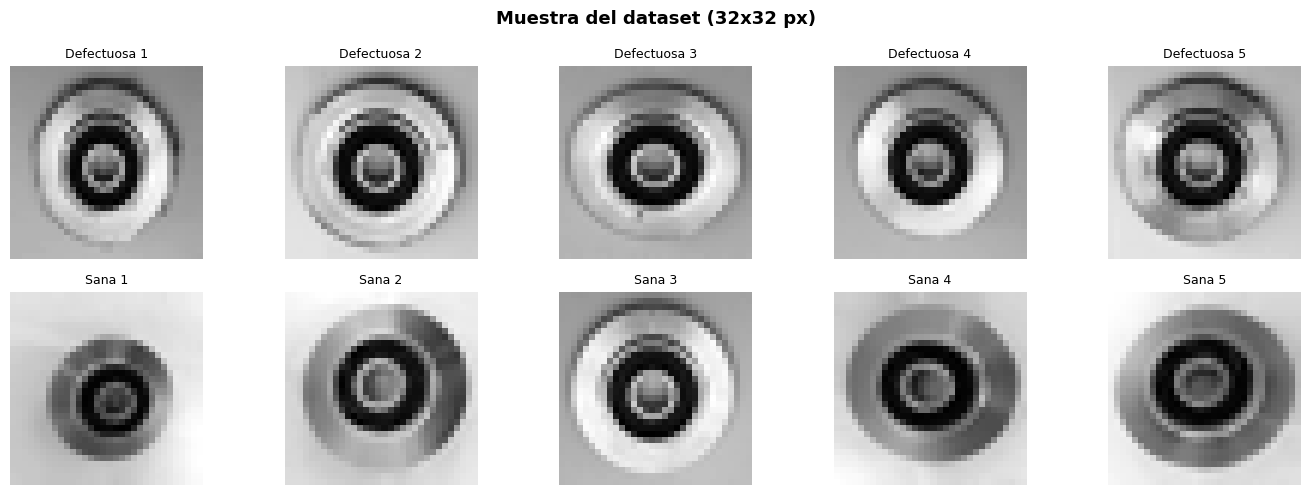

In [7]:
# visualizamos unas cuantas imágenes para confirmar que cargaron bien
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i in range(5):
    axes[0, i].imshow(imgs_def[i], cmap='gray')
    axes[0, i].set_title(f"Defectuosa {i+1}", fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(imgs_ok[i], cmap='gray')
    axes[1, i].set_title(f"Sana {i+1}", fontsize=9)
    axes[1, i].axis('off')
plt.suptitle("Muestra del dataset (32x32 px)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# apilamos defectuosas (label=1) y sanas (label=0) en un solo dataset
X_imagenes = np.concatenate([imgs_def, imgs_ok], axis=0)
y_labels   = np.array([1] * 300 + [0] * 300)

print(f"Dataset total: {X_imagenes.shape}")

print("Calculando persistencia cubica (puede tardar ~30s)...")
cp_real = CubicalPersistence(homology_dimensions=[0, 1], n_jobs=-1)
diagramas_reales = cp_real.fit_transform(X_imagenes)

print(f"Diagramas shape: {diagramas_reales.shape}")


Dataset total: (600, 32, 32)
Calculando persistencia cubica (puede tardar ~30s)...
Diagramas shape: (600, 133, 3)


In [9]:
# convertimos los diagramas a imagenes de persistencia
print("Generando imagenes de persistencia...")
pi = PersistenceImage(sigma=0.1, n_bins=20, n_jobs=-1)
X_tda = pi.fit_transform(diagramas_reales)

print(f"Persistence images shape: {X_tda.shape}")

# aplanamos: cada imagen de persistencia -> vector 1D
X_tda_flat = X_tda.reshape(X_tda.shape[0], -1)
print(f"Vectores topologicos shape: {X_tda_flat.shape}")

Generando imagenes de persistencia...
Persistence images shape: (600, 2, 20, 20)
Vectores topologicos shape: (600, 800)


In [10]:
# tambien preparamos los pixeles crudos para el modelo clasico
X_clasico = X_imagenes.reshape(X_imagenes.shape[0], -1)
print(f"Pixeles aplanados shape: {X_clasico.shape}")

Pixeles aplanados shape: (600, 1024)


### Benchmark: TDA vs Clásico

Entrenen un RandomForestClassifier comparando los enfoques:

1. **Modelo A (Clásico):**
Entrenado usando únicamente los píxeles aplanados (1024 variables).

2. **Modelo B (Topológico):**
Entrenado usando únicamente las Imágenes de Persistencia (Vectores Topológicos).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier #el randomforest q nos piden
from sklearn.metrics import accuracy_score, classification_report

X_tda_train, X_tda_test, y_train, y_test = train_test_split(
    X_tda_flat, y_labels, test_size=0.2, random_state=42
)
X_cl_train, X_cl_test, _, _ = train_test_split(
    X_clasico, y_labels, test_size=0.2, random_state=42
)

indices_test = np.arange(len(y_labels))
_, idx_test = train_test_split(indices_test, test_size=0.2, random_state=42)

print(f"Train: {len(y_train)} imagenes | Test: {len(y_test)} imagenes")

Train: 480 imagenes | Test: 120 imagenes


In [12]:
print("Entrenando Modelo Clasico (pixeles)...")
rf_clasico = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clasico.fit(X_cl_train, y_train)
acc_clasico = accuracy_score(y_test, rf_clasico.predict(X_cl_test))

print("Entrenando Modelo TDA (topologia)...")
rf_tda = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_tda.fit(X_tda_train, y_train)
acc_tda = accuracy_score(y_test, rf_tda.predict(X_tda_test))

print("\n========== BENCHMARK ===========")
print(f"Modelo Clasico  (pixeles)  : {acc_clasico:.2%}")
print(f"Modelo TDA      (topologia): {acc_tda:.2%}")

Entrenando Modelo Clasico (pixeles)...
Entrenando Modelo TDA (topologia)...

========== BENCHMARK ===========
Modelo Clasico  (pixeles)  : 94.17%
Modelo TDA      (topologia): 95.00%


In [13]:

print(" <3<3<3<3<3<3<3<3<3<3<3<3<3<3 Modelo Clasico")

print(classification_report(y_test, rf_clasico.predict(X_cl_test),
                            target_names=['Sana', 'Defectuosa']))


print(" <3<3<3<3<3<3<3<3<3<3<3<3<3<3 Modelo TDA")

print(classification_report(y_test, rf_tda.predict(X_tda_test),
                            target_names=['Sana', 'Defectuosa']))

 <3<3<3<3<3<3<3<3<3<3<3<3<3<3 Modelo Clasico
              precision    recall  f1-score   support

        Sana       0.89      1.00      0.94        58
  Defectuosa       1.00      0.89      0.94        62

    accuracy                           0.94       120
   macro avg       0.95      0.94      0.94       120
weighted avg       0.95      0.94      0.94       120

 <3<3<3<3<3<3<3<3<3<3<3<3<3<3 Modelo TDA
              precision    recall  f1-score   support

        Sana       0.91      1.00      0.95        58
  Defectuosa       1.00      0.90      0.95        62

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120



### El "Aha Moment" (Test de Robustez)

Probablemente, ambos modelos obtengan un Accuracy similar (ej. 85%). Para demostrar el poder del TDA, ejecuten este test:

- **Reto**: Roten todas las imágenes del set de prueba (X_test) 90 grados, o gírenlas verticalmente (Flip). Vuelvan a evaluar ambos modelos.
- **Resultado**: El Modelo Clásico colapsará drásticamente (los píxeles se movieron). El Modelo TDA mantendrá su precisión casi intacta, porque un agujero sigue siendo un agujero, sin importar cómo rotes la pieza.

In [14]:
X_img_test_orig = X_imagenes[idx_test]
X_img_test_rot  = np.rot90(X_img_test_orig, k=1, axes=(1, 2))

X_cl_test_rot = X_img_test_rot.reshape(len(idx_test), -1)
acc_clasico_rot = accuracy_score(y_test, rf_clasico.predict(X_cl_test_rot))

print("Recalculando persistencia de imagenes rotadas...")
diag_rot    = cp_real.transform(X_img_test_rot)
X_tda_rot   = pi.transform(diag_rot).reshape(len(idx_test), -1)
acc_tda_rot = accuracy_score(y_test, rf_tda.predict(X_tda_rot))

print("\nTEST DE ROBUSTEZ (rotacion 90) ")
print(f"{'Modelo':<20} {'Normal':>10} {'Rotado':>10} {'Caida':>10}")
print("-" * 52)
print(f"{'Clasico (pixeles)':<20} {acc_clasico:>10.2%} {acc_clasico_rot:>10.2%} {acc_clasico - acc_clasico_rot:>10.2%}")
print(f"{'TDA (topologia)':<20} {acc_tda:>10.2%} {acc_tda_rot:>10.2%} {acc_tda - acc_tda_rot:>10.2%}")
print()
print("Conclusion: el modelo TDA mantiene su precision")
print("porque un agujero sigue siendo un agujero sin importar la rotacion.")

Recalculando persistencia de imagenes rotadas...

TEST DE ROBUSTEZ (rotacion 90) 
Modelo                   Normal     Rotado      Caida
----------------------------------------------------
Clasico (pixeles)        94.17%     81.67%     12.50%
TDA (topologia)          95.00%     95.00%      0.00%

Conclusion: el modelo TDA mantiene su precision
porque un agujero sigue siendo un agujero sin importar la rotacion.


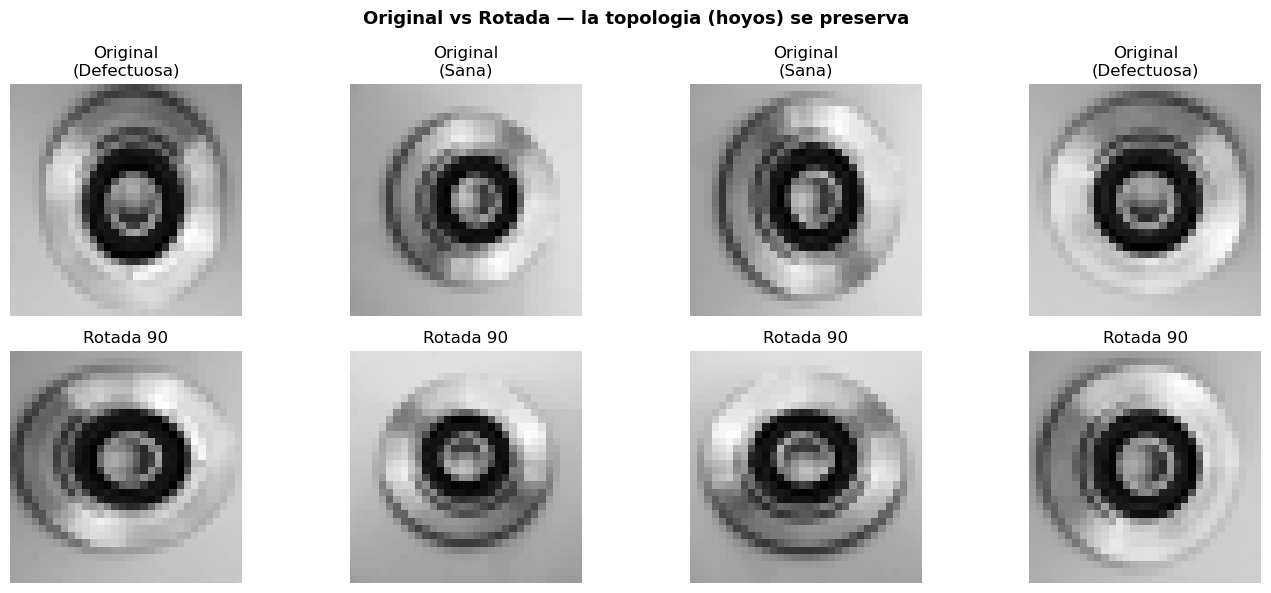

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i in range(4):
    axes[0, i].imshow(X_img_test_orig[i], cmap='gray')
    axes[0, i].set_title(f"Original\n({'Defectuosa' if y_test[i]==1 else 'Sana'})")
    axes[0, i].axis('off')

    axes[1, i].imshow(X_img_test_rot[i], cmap='gray')
    axes[1, i].set_title("Rotada 90")
    axes[1, i].axis('off')

plt.suptitle("Original vs Rotada — la topologia (hoyos) se preserva", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

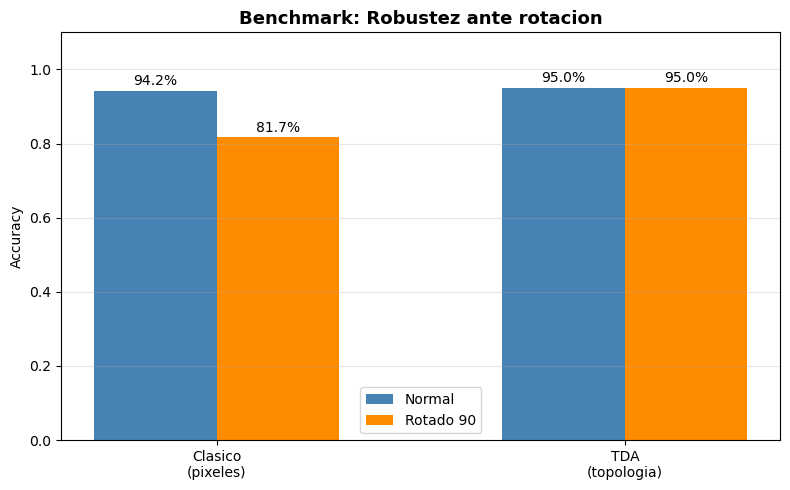


El modelo TDA es invariante a rotaciones.
Un agujero sigue siendo un agujero sin importar la orientacion.


In [16]:
# GRAFICA RESUMEN FINAL: barras comparativas

labels_bar = ['Clasico\n(pixeles)', 'TDA\n(topologia)']
normal_accs  = [acc_clasico, acc_tda]
rotated_accs = [acc_clasico_rot, acc_tda_rot]

x = np.arange(len(labels_bar))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, normal_accs,  width, label='Normal',  color='steelblue')
bars2 = ax.bar(x + width/2, rotated_accs, width, label='Rotado 90', color='darkorange')

ax.set_ylabel('Accuracy')
ax.set_title('Benchmark: Robustez ante rotacion', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels_bar)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.1%}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nEl modelo TDA es invariante a rotaciones.")
print("Un agujero sigue siendo un agujero sin importar la orientacion.")